# Deconfined quark matter: four models, one set of axes

Cell 1 imports, cell 2 builds one table per model from a CONFIG block the
reader edits, cell 3 draws them on shared axes and reports E/A at the
surface, cell 4 times NJL across its modes and sectors.

In [1]:
import sys
import time
from dataclasses import replace
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib

# A plain `python quark_timing.py` must not open a window and block; under a
# kernel the notebook's own backend is left alone.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from eos import abpr, alphabag, njl, vmit
from eos.njl.table import rows_from_result as njl_rows_from_result
from eos.astro.tov import compute_tov_sequence, find_mmax_precise
from eos.general.figure_style import (LABELS, OKAB_CAT, log_decades,
                                      panel_label, paper_grid)
from eos.general.sound_speeds import sound_speed_eq
from eos.general.state import EOSTable_for_TOV
from eos.mixed import njl_phase
from eos.mixed import eos_table as mixed_table
from eos.mixed.species import SpeciesFlags as MixedFlags

## The four tables

One block per model. Everything above each `---` divider is a choice; the
lines below it are the same four statements in every block (build the
parameter set, solve the grid, flatten to rows, print what came back) and
are not edited to change the physics.

A sweep is one named parameter taking a list of values with the rest of the
set held: `<MODEL>_SWEEP = (name, values)` and `<MODEL>_HELD` holding
everything except that name.

In [2]:
TABLES = {}       # label -> rows, read by cell 3
LABEL_MODEL = {}  # label -> which model produced it
PARS = {}         # model name -> the parameter set its first curve was solved at


def summarise(label, rows, n_requested, seconds):
    """Points solved / requested, where P turns positive, and the cost.

    Non-convergence is a return value: a thin table is a statement about where
    the phase exists, so it is counted and printed rather than raised on.
    """
    if not rows:
        print(f"  [{label:32s}] {0:3d}/{n_requested} points solved   "
              f"{seconds:6.2f} s")
        return
    ascending = sorted(rows, key=lambda row: row["n_B"])
    positive = [row["n_B"] for row in ascending if row["P"] > 0.0]
    onset = f"{positive[0]:.3f}" if positive else "  none"
    print(f"  [{label:32s}] {len(rows):3d}/{n_requested} points   "
          f"P > 0 from n_B = {onset} fm^-3   "
          f"{seconds:7.2f} s   {1e3 * seconds / len(rows):8.2f} ms/pt")


# ===========================================================================
# njl -- three-flavour NJL with 't Hooft term, RG-consistent vacuum
#
# INPUTS
#   NJL_SET      a published set: "rkh" | "rg_njl1" | "kunkel" |
#                "gluon_exchange"
#   NJL_HELD     fields of njl.Parameters, any float unless noted:
#                Lambda, GS_Lambda2, K_Lambda5 (the vacuum fit);
#                m_u, m_d, m_s (current masses, MeV);
#                eta_D (diquark coupling, G_D = eta_D G_S);
#                eta_V (vector coupling, G_V = eta_V G_S);
#                vector_form "constant" | "power_law" | "gluon_exchange"
#                  (njl.VECTOR_FORMS), with alpha, n_ref, G_V0_over_GS, M_g
#                  the shape parameters those two forms read;
#                lambda_UV (RG cutoff in units of Lambda; 10.0 is the shipped
#                  default, 1.0 the bit-for-bit sharp-cutoff legacy)
#   NJL_MODE     "beta_eq_neutrinoless" | "beta_eq_neutrino_trapped" (needs
#                Y_Le) | "fixed_YC" (Y_C) | "fixed_YC_YS" (Y_C, Y_S).
#                Y_Lmu raises: the muon FAMILY is not a conserved charge here.
#   NJL_SPECIES  njl.SpeciesFlags(csc, muons, thermal_neutrinos, photons,
#                two_flavour), each True | False. hyperons, deltas and
#                thermal_mesons are fixed False and raise.
#   NJL_NB, NJL_T   the grid: densities in fm^-3, one temperature in MeV
#   NJL_PATTERNS any subset of ("unpaired", "2SC", "uSC", "dSC", "CFL",
#                "free"), or None for njl's default enumeration. A
#                restriction is a declaration, not a guarantee: read
#                `pattern_realised` for what the solve actually landed on.
#   NJL_BACKEND  "reference" | "fast"
#
# NO CONSTRUCTION IS IMPOSED HERE, AND THE CHOICE IS NOT THIS BLOCK'S
#   What a fixed-n_B table returns is the lowest FREE ENERGY candidate at
#   each density. Where 2SC and CFL exchange stability the line HOPS between
#   them and P and mu_B both fall as n_B rises: an artefact of comparing at
#   fixed density (`eos.njl.solver`'s module docstring), not a transition,
#   and cell 3 draws it as a fold. NJL_PATTERNS only says which candidates
#   are enumerated -- ("2SC",) alone traces that branch over its whole domain,
#   metastable continuation included -- never how two of them are joined.
#   THE CONSTRUCTION IS `eos.mixed`, and it is one scalar rather than a menu:
#
#       from eos.mixed import eos_table as mixed_table, njl_phase
#       phases = (njl_phase(par, NJL_SPECIES, patterns=("2SC",)),
#                 njl_phase(par, NJL_SPECIES, patterns=("CFL",)))
#       rows, windows = mixed_table(phases, NJL_MODE, mixed_species,
#                                   {"nB": NJL_NB, "T": [NJL_T]}, eta=1.0)
#
#   eta = 1 is Maxwell (each phase separately neutral, P constant across the
#   window), eta = 0 is Gibbs (only the volume average is neutral, P rises
#   through it), and eta in between stands in for the surface tension and
#   Coulomb cost of the mixed-phase structures. The windows come back with
#   the rows because the boundaries ARE part of the answer.
#   "Largest P at fixed mu_B" is NOT a third option: equal P at equal mu_B
#   and keeping the larger P are one statement, so that IS eta = 1. It is
#   also what `njl_phase` already does internally -- at fixed potentials it
#   enumerates the patterns and keeps the largest pressure, which is why a
#   pure-phase mixed call does not fold the way this block's table does.
#   Pairing two branches of one functional is `enjl_branch_pair`'s pattern;
#   for njl it is the two `njl_phase` calls above and is not a shipped pair.
#   Filter on `pattern_realised` before comparing branches by hand: below the
#   transition Delta_1 and Delta_2 collapse to zero and a CFL-layout solve
#   comes back as 2SC wearing the CFL seed's layout.
#
# OUTPUT COLUMNS, per row
#   n_B, T, chi (= 1), phase (= "Q"), P, eps, s, S_per_B,
#   mu_B, mu_C, mu_S, mu_e, Y_C, Y_S, Y_u, Y_d, Y_s, Y_e, Y_mu-,
#   M_u, M_d, M_s (constituent masses),
#   pattern, pattern_realised, gapless, Delta_1, Delta_2, Delta_3,
#   mu_3, mu_8 (the colour potentials colour neutrality needed),
#   and under trapping also Y_nue, mu_nue.
# ===========================================================================
NJL_SET = "rkh"
NJL_HELD = dict(eta_V=1, vector_form="constant", alpha=2.0 / 3.0,
                n_ref=1, G_V0_over_GS=0.5, M_g=500.0)
NJL_SWEEP = ("eta_D", (0.5,1.,1.5))
NJL_MODE = "beta_eq_neutrinoless"
NJL_SPECIES = njl.SpeciesFlags(csc=True, muons=False, thermal_neutrinos=False,
                               photons=False, two_flavour=False)
# A paired point diagonalises the BdG problem at every quadrature node of
# every residual evaluation: ~4 s/point at T = 0 even on the fast backend, so
# this grid is short on purpose.
NJL_NB = np.linspace(0.5, 1.5, 200)
NJL_T = 0.0
NJL_PATTERNS = ("unpaired", "2SC", "CFL")
NJL_BACKEND = "fast"
# WHICH BRANCH IS KEPT WHERE TWO OF THEM COMPETE:
#   "free_energy"  the lowest f at each FIXED n_B -- one eos_table call over
#                  NJL_PATTERNS, and what the model returns on its own.
#   "max_P"        each pattern traced ALONE, then at equal mu_B the branch
#                  with the larger P. One table per pattern, so it costs
#                  len(NJL_PATTERNS) times as much. Needs csc=True.
NJL_SELECTION = "free_energy"
# ---------------------------------------------------------------------------
njl_base = replace(njl.Parameters.named(NJL_SET), **NJL_HELD)
njl_sweep_name, njl_sweep_values = NJL_SWEEP
# A restriction of the pairing enumeration is only a statement when there is a
# pairing sector: with csc=False an explicit pattern list is refused.
njl_patterns = NJL_PATTERNS if NJL_SPECIES.csc else None
if NJL_SELECTION == "max_P" and njl_patterns is None:
    raise ValueError("NJL_SELECTION = 'max_P' compares branches and csc is "
                     "False, so there is only one; use 'free_energy'")


def max_P_envelope(branch_rows):
    """The rows that survive "largest P at equal mu_B" -- the Maxwell rule.

    `branch_rows` maps a pattern to the rows REALISED on that branch. A row is
    dropped when another branch reaches a higher pressure at the same mu_B.
    Maximising P at fixed mu_i and imposing equal P at equal mu_B are one
    statement, and each branch here is neutralised by its own leptons, which
    is what makes the comparison meaningful.

    A branch is ABSENT outside its own converged mu_B range rather than
    extrapolated: inventing a pressure below a spinodal would let a phase that
    does not exist win. Only solved rows are kept -- no interpolated edge rows
    -- so a first-order transition shows as a GAP in n_B, which is the density
    jump at constant P, and not as a drawn plateau.
    """
    ordered = {}
    for pattern, rows in branch_rows.items():
        if not rows:
            continue
        ascending = sorted(rows, key=lambda row: row["mu_B"])
        ordered[pattern] = (np.array([row["mu_B"] for row in ascending]),
                            np.array([row["P"] for row in ascending]))

    kept = []
    for pattern, rows in branch_rows.items():
        for row in rows:
            beaten = False
            for other, (mu, P) in ordered.items():
                if other == pattern or not mu[0] <= row["mu_B"] <= mu[-1]:
                    continue
                if np.interp(row["mu_B"], mu, P) > row["P"]:
                    beaten = True
                    break
            if not beaten:
                kept.append(row)

    # Two branches can survive at ONE density with the same pressure, because
    # they are the same state reached twice: a 2SC solve whose gap collapsed
    # IS the unpaired solve, and neither beats the other. Keep the higher
    # pressure at each density, which on a tie is either of them.
    unique = {}
    for row in sorted(kept, key=lambda row: (row["n_B"], -row["P"])):
        unique.setdefault(round(row["n_B"], 9), row)
    return sorted(unique.values(), key=lambda row: row["n_B"])


print(f"=== njl, {NJL_MODE}, T = {NJL_T} MeV, csc={NJL_SPECIES.csc}, "
      f"patterns={njl_patterns}, selection={NJL_SELECTION!r} ===")
for value in njl_sweep_values:
    par = replace(njl_base, **{njl_sweep_name: value})
    axes_njl = {"nB": NJL_NB, "T": np.array([NJL_T])}
    start = time.perf_counter()

    if NJL_SELECTION == "free_energy":
        table = njl.eos_table(par, NJL_MODE, NJL_SPECIES, axes_njl,
                              patterns=njl_patterns, backend=NJL_BACKEND)
        rows = njl_rows_from_result(table)
    elif NJL_SELECTION == "max_P":
        branch_rows = {}
        for pattern in NJL_PATTERNS:
            table = njl.eos_table(par, NJL_MODE, NJL_SPECIES, axes_njl,
                                  patterns=(pattern,), backend=NJL_BACKEND)
            # A CFL-LAYOUT SOLVE IS NOT A CFL POINT: below the transition
            # Delta_1 and Delta_2 collapse to zero and what comes back is 2SC
            # wearing the CFL seed's layout, so the branch is what was
            # REALISED, not what was asked for.
            branch_rows[pattern] = [row for row in njl_rows_from_result(table)
                                    if row["pattern_realised"] == pattern]
        rows = max_P_envelope(branch_rows)
    else:
        raise ValueError(f"NJL_SELECTION is 'free_energy' or 'max_P'; "
                         f"got {NJL_SELECTION!r}")

    seconds = time.perf_counter() - start
    label = f"njl {njl_sweep_name} = {value:g}"
    TABLES[label] = rows
    LABEL_MODEL[label] = "njl"
    summarise(label, rows, len(NJL_NB), seconds)
    if NJL_SELECTION == "max_P":
        won = {p: sum(1 for row in rows if row["pattern_realised"] == p)
               for p in NJL_PATTERNS}
        print(f"  {'':32s}   winners: {won}")
PARS["njl"] = replace(njl_base, **{njl_sweep_name: njl_sweep_values[0]})


# ===========================================================================
# vmit -- vector-enhanced MIT bag
#
# INPUTS
#   VMIT_HELD    fields of vmit.Parameters: m_u, m_d, m_s (MeV),
#                a (vector coupling g_V^2/m_V^2, fm^2), B4 (bag constant
#                B^(1/4), MeV). One published set, vmit.Parameters.default().
#   VMIT_MODE    "beta_eq_neutrinoless" | "beta_eq_neutrino_trapped" (Y_Le)
#                | "fixed_YC" (Y_C) | "fixed_YC_YS" (Y_C, Y_S). Y_Lmu raises.
#   VMIT_SPECIES vmit.SpeciesFlags(photons, two_flavour) True | False;
#                muons, thermal_neutrinos, hyperons, deltas and thermal_mesons
#                raise.
#   VMIT_NB, VMIT_T   the grid, fm^-3 and MeV
#   no backend argument: this model has no backends/ and no pairing sector.
#
# OUTPUT COLUMNS, per row
#   n_B, T, chi (= 1), phase (= "Q"), P, eps, s, S_per_B,
#   mu_B, mu_C, mu_S, mu_e, Y_C, Y_S, Y_u, Y_d, Y_s, Y_e,
#   and under trapping also Y_nue, mu_nue. No gap columns: unpaired matter.
# ===========================================================================
VMIT_HELD = dict(m_u=5.0, m_d=7.0, m_s=150.0, a=0.2)
VMIT_SWEEP = ("B4", (170.0, 180.0, 190.0))
VMIT_MODE = "beta_eq_neutrinoless"
VMIT_SPECIES = vmit.SpeciesFlags(photons=False, two_flavour=False)
VMIT_NB = np.linspace(0.2, 1.6, 60)
VMIT_T = 0.0
# ---------------------------------------------------------------------------
vmit_base = replace(vmit.Parameters.default(), **VMIT_HELD)
vmit_sweep_name, vmit_sweep_values = VMIT_SWEEP

print(f"\n=== vmit, {VMIT_MODE}, T = {VMIT_T} MeV ===")
for value in vmit_sweep_values:
    par = replace(vmit_base, **{vmit_sweep_name: value})
    start = time.perf_counter()
    rows = vmit.eos_table(par, VMIT_MODE, VMIT_SPECIES,
                          {"nB": VMIT_NB, "T": np.array([VMIT_T])}, rows=True)
    seconds = time.perf_counter() - start
    label = f"vmit {vmit_sweep_name} = {value:g}"
    TABLES[label] = rows
    LABEL_MODEL[label] = "vmit"
    summarise(label, rows, len(VMIT_NB), seconds)
PARS["vmit"] = replace(vmit_base, **{vmit_sweep_name: vmit_sweep_values[0]})


# ===========================================================================
# alphabag -- O(alpha_s) bag model, here in its colour-flavour-locked phase
#
# INPUTS
#   AB_HELD      fields of alphabag.Parameters: m_u, m_d (MeV, massless by
#                default), m_s (MeV), alpha (alpha_s), B4 (MeV),
#                tc_coeff (T_c = tc_coeff * Delta0).
#   AB_MODE      the four modes vmit has, plus "cfl". In cfl the locking
#                fixes Y_C = 0 and Y_S = +1, so no fraction is free; the
#                condition is the gap Delta0, passed through `fixed`.
#   AB_DELTA0    the CFL gap in MeV -- a per-call CONDITION here, not a
#                parameter of the set.
#   AB_SPECIES   alphabag.SpeciesFlags(photons, thermal_neutrinos,
#                two_flavour) True | False; gluons keeps both values in the
#                unpaired modes and RAISES in cfl (locking leaves one massless
#                gauge boson, the rotated photon); muons and the hadronic
#                sectors raise everywhere.
#   AB_NB, AB_T  the grid, fm^-3 and MeV
#
# OUTPUT COLUMNS, per row
#   n_B, T, chi (= 1), phase (= "Q"), P, eps, s, S_per_B,
#   mu_B, mu_C, mu_S, mu_e, Y_C, Y_S, Y_u, Y_d, Y_s, Y_e,
#   plus Delta0 (asked for) and Delta (at this T) in cfl,
#   plus Y_nue, mu_nue under trapping.
# ===========================================================================
AB_HELD = dict(m_u=0.0, m_d=0.0, m_s=150.0, alpha=0.3)
AB_SWEEP = ("B4", (155.0, 165.0))
AB_MODE = "cfl"
AB_DELTA0 = 100.0
AB_SPECIES = alphabag.SpeciesFlags(photons=False, thermal_neutrinos=False,
                                   two_flavour=False)
AB_NB = np.linspace(0.2, 1.6, 60)
AB_T = 0.0
# ---------------------------------------------------------------------------
ab_base = replace(alphabag.Parameters.default(), **AB_HELD)
ab_sweep_name, ab_sweep_values = AB_SWEEP

print(f"\n=== alphabag, {AB_MODE}, T = {AB_T} MeV, "
      f"Delta0 = {AB_DELTA0:g} MeV ===")
for value in ab_sweep_values:
    par = replace(ab_base, **{ab_sweep_name: value})
    start = time.perf_counter()
    rows = alphabag.eos_table(par, AB_MODE, AB_SPECIES,
                              {"nB": AB_NB, "T": np.array([AB_T])},
                              fixed={"Delta0": AB_DELTA0}, rows=True)
    seconds = time.perf_counter() - start
    label = f"alphabag {ab_sweep_name} = {value:g}"
    TABLES[label] = rows
    LABEL_MODEL[label] = "alphabag"
    summarise(label, rows, len(AB_NB), seconds)
PARS["alphabag"] = replace(ab_base, **{ab_sweep_name: ab_sweep_values[0]})


# ===========================================================================
# abpr -- the CFL bag model of Alford, Braby, Paris and Reddy
#
# INPUTS
#   ABPR_HELD    fields of abpr.Parameters: m_s (MeV), Delta0 (the CFL gap,
#                MeV -- a PARAMETER here, unlike alphabag), a4 (the pQCD
#                factor 1 - 2 alpha_s/pi, typically 0.6-1.0, 1.0 = free gas),
#                B4 (MeV).
#   mode         cfl is the only mode this model has, so it defaults and is
#                not passed.
#   ABPR_SPECIES abpr.SpeciesFlags() and nothing else: every flag raises,
#                which is the model stating what phase it IS.
#   ABPR_NB      the grid, fm^-3. T = 0 only; a longer temperature axis
#                raises.
#
# OUTPUT COLUMNS, per row
#   n_B, T, chi (= 1), phase (= "Q"), P, eps, s, S_per_B,
#   mu_B, mu_C, mu_S, mu_e, Y_C, Y_S, Y_u, Y_d, Y_s, Y_e,
#   Delta0, Delta. No convergence-thinned rows to expect: the density inverse
#   is closed form.
# ===========================================================================
ABPR_HELD = dict(m_s=150.0, a4=0.7, B4=135.0)
ABPR_SWEEP = ("Delta0", (60.0, 80.0, 100.0))
ABPR_NB = np.linspace(0.2, 1.6, 60)
# ---------------------------------------------------------------------------
abpr_base = replace(abpr.Parameters.default(), **ABPR_HELD)
abpr_sweep_name, abpr_sweep_values = ABPR_SWEEP

print("\n=== abpr, cfl (its only mode), T = 0 MeV ===")
for value in abpr_sweep_values:
    par = replace(abpr_base, **{abpr_sweep_name: value})
    start = time.perf_counter()
    rows = abpr.eos_table(par, axes={"nB": ABPR_NB, "T": np.array([0.0])},
                          rows=True)
    seconds = time.perf_counter() - start
    label = f"abpr {abpr_sweep_name} = {value:g}"
    TABLES[label] = rows
    LABEL_MODEL[label] = "abpr"
    summarise(label, rows, len(ABPR_NB), seconds)
PARS["abpr"] = replace(abpr_base, **{abpr_sweep_name: abpr_sweep_values[0]})


# ===========================================================================
# mixed -- the two NJL branches coupled as a MIXED PHASE (eos.mixed)
#
# The selection above compares branches; this couples them. Where a
# construction says one phase or the other, a mixed phase says both at once,
# in a volume fraction chi that the solve finds.
#
# INPUTS
#   MIXED_ETA    None SKIPS this block. Otherwise a float in [0, 1]: how much
#                of electric neutrality is imposed phase by phase rather than
#                on the mixture as a whole.
#                  eta = 1  Maxwell -- each phase separately neutral, P
#                           constant across the window.
#                  eta = 0  Gibbs -- only the volume average is neutral, so
#                           each phase is charged and P rises through it.
#                  between  stands in for the surface tension and Coulomb
#                           cost of the mixed-phase structures.
#                It is a scalar per call, not an axis: it changes the shape of
#                the unknown vector.
#   MIXED_BRANCHES  the two patterns to couple, LOW-DENSITY PHASE FIRST. Each
#                becomes a `njl_phase` closing over its own `patterns`
#                restriction -- the pairing IS this engine's parameter
#                argument, the way `enjl_branch_pair` pairs two branches of
#                one functional.
#   MIXED_NB, MIXED_T  the grid, fm^-3 and MeV
#   the parameter set, njl flags, mode and backend are the njl block's, so the
#                branches here are the same physics NJL_SELECTION compares.
#   species      eos.mixed.SpeciesFlags -- section 4's six names at the
#                mixture level; the per-phase ones are delegated to the two
#                Phase objects, photons and thermal_neutrinos counted once.
#
# OUTPUT: (rows, windows), not just rows. Rows carry n_B, T, eta, chi, phase,
#   P, eps, s, S_per_B, mu_B, mu_C, mu_S, Y_C, Y_S, the per-phase shares
#   Y_B_H/Y_C_H/Y_S_H and Y_B_Q/Y_C_Q/Y_S_Q, every species fraction weighted
#   by chi, and the leptons split three ways (Y_L_H, Y_L_Q local, Y_L_G
#   global). The windows carry n_onset and n_offset per line and ARE part of
#   the answer. No gap column: read the gaps off the branch tables above.
#   window_only=True (the default) solves the mixed system only between the
#   located boundaries, so "points solved" counts the window, not the grid.
#
# MEASURED on this pairing at eta_D = 1.45, T = 0, backend fast. Two runs,
# both with eta_V = 0.5, n_ref = 0.48 in the first and this block's own held
# set in the second:
#   eta = 0, 12 densities 0.5-1.5   2698 s,  3 rows, window 0.500 -> 1.193
#   eta = 0,  8 densities 0.5-1.5   3442 s,  2 rows, window 0.536 -> 1.085
#   eta = 1, 12 densities 0.5-1.5    775 s,  0 rows, NO window located
#             (n_onset = nan) -- although the max_P envelope above finds a
#             2SC -> CFL crossing for the same parameters, so the crossing
#             exists and the eta = 1 locator did not reach it on its default
#             scan.
# Both slots are a paired NJL solve re-entered at every potential the locator
# tries -- hours, not minutes -- which is why this block is off unless
# MIXED_ETA is set. Fewer grid points do not make it cheaper: the cost is in
# locating the window, not in the rows.
# ===========================================================================
MIXED_ETA = None
MIXED_BRANCHES = ("2SC", "CFL")
MIXED_NB = np.linspace(0.5, 1.5, 12)
MIXED_T = 0.0
# ---------------------------------------------------------------------------
if MIXED_ETA is None:
    print("\n=== mixed: skipped, MIXED_ETA is None ===")
else:
    lo_pattern, hi_pattern = MIXED_BRANCHES
    phases = (njl_phase(PARS["njl"], NJL_SPECIES, patterns=(lo_pattern,),
                        backend=NJL_BACKEND),
              njl_phase(PARS["njl"], NJL_SPECIES, patterns=(hi_pattern,),
                        backend=NJL_BACKEND))

    print(f"\n=== mixed, {lo_pattern} + {hi_pattern}, {NJL_MODE}, "
          f"T = {MIXED_T} MeV, eta = {MIXED_ETA:g} ===")
    start = time.perf_counter()
    mixed_rows, mixed_windows = mixed_table(
        phases, NJL_MODE, MixedFlags(),
        {"nB": MIXED_NB, "T": np.array([MIXED_T])}, eta=MIXED_ETA)
    seconds = time.perf_counter() - start

    label = f"mixed {lo_pattern}+{hi_pattern} eta = {MIXED_ETA:g}"
    TABLES[label] = mixed_rows
    LABEL_MODEL[label] = "mixed"
    summarise(label, mixed_rows, len(MIXED_NB), seconds)
    # The window is part of the result, not something to recover by scanning
    # the rows for where chi left [0, 1]. A nan boundary is a return value: it
    # says the locator found no coexistence on this line.
    for line, window in mixed_windows.items():
        print(f"  {'':32s}   window n_onset = {window.n_onset:.4f}, "
              f"n_offset = {window.n_offset:.4f} fm^-3")

=== njl, beta_eq_neutrinoless, T = 0.0 MeV, csc=True, patterns=('unpaired', '2SC', 'CFL'), selection='free_energy' ===
  [njl eta_D = 0.5                 ] 200/200 points   P > 0 from n_B = 0.500 fm^-3   1449.33 s    7246.66 ms/pt
  [njl eta_D = 1                   ] 200/200 points   P > 0 from n_B = 0.500 fm^-3    254.00 s    1269.99 ms/pt
  [njl eta_D = 1.5                 ] 200/200 points   P > 0 from n_B = 0.500 fm^-3    100.09 s     500.46 ms/pt

=== vmit, beta_eq_neutrinoless, T = 0.0 MeV ===
  [vmit B4 = 170                   ]  60/60 points   P > 0 from n_B = 0.390 fm^-3      0.02 s       0.31 ms/pt
  [vmit B4 = 180                   ]  60/60 points   P > 0 from n_B = 0.461 fm^-3      0.02 s       0.39 ms/pt
  [vmit B4 = 190                   ]  60/60 points   P > 0 from n_B = 0.508 fm^-3      0.02 s       0.34 ms/pt

=== alphabag, cfl, T = 0.0 MeV, Delta0 = 100 MeV ===
  [alphabag B4 = 155               ]  60/60 points   P > 0 from n_B = 0.319 fm^-3      0.01 s       0.18 ms/p

## The figures

Five panels on shared axes, then the M-R sequence each table gives, then
E/A at the self-bound surface. Colour is the model, linestyle the entry
within that model's sweep.

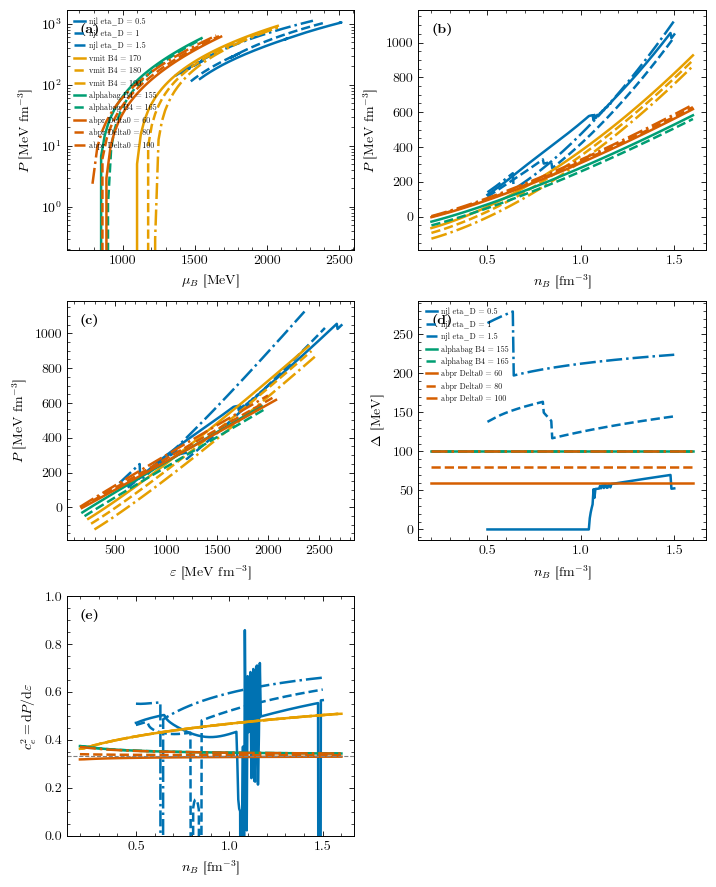


=== M-R ===
  [njl      ]  30 stars, M_max = 1.807 M_sun at R = 8.57 km, eps_c = 1703 MeV/fm^3
  [vmit     ]  30 stars, M_max = 1.729 M_sun at R = 8.60 km, eps_c = 1822 MeV/fm^3
  [alphabag ]  30 stars, M_max = 1.960 M_sun at R = 10.51 km, eps_c = 1177 MeV/fm^3
  [abpr     ]  30 stars, M_max = 2.182 M_sun at R = 12.04 km, eps_c = 899 MeV/fm^3


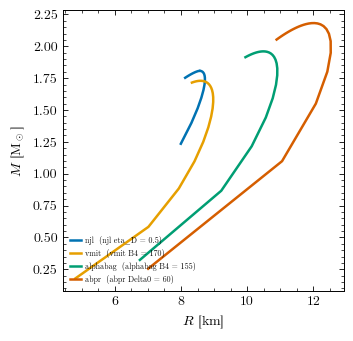


=== E/A at P = 0, T = 0 (three flavours) ===
  [njl      ] no surface: P(n_B) does not rise through zero anywhere in [0.02, 1.5] fm^-3 (P spans [0.9944, 1113] MeV/fm^3); this parameter set has no self-bound surface there
  [vmit     ] E/A =  1087.48 MeV at n_B = 0.3783 fm^-3, Y_S = 0.8207, below iron: False
  [alphabag ] E/A =   988.23 MeV at n_B = 0.3350 fm^-3, Y_S = 0.7880, below iron: False
  [abpr     ] E/A =   874.73 MeV at n_B = 0.2133 fm^-3, Y_S = 1.0000, below iron: True


In [3]:
# The M-R sequence: central energy densities and how many stars per model.
MR_N_STARS = 30
MR_CRUST = "No"        # 'No' | 'BPS' | one of the compose_* crusts

MODEL_COLOUR = dict(zip(("njl", "vmit", "alphabag", "abpr", "mixed"),
                        OKAB_CAT))
SWEEP_STYLES = ("-", "--", "-.", ":")
# ---------------------------------------------------------------------------


def columns(rows, keys):
    """The named row fields as parallel arrays, ascending in density.

    A key absent from the rows is simply not returned, which is how a model
    without a pairing sector is kept out of the gap panel.
    """
    ascending = sorted(rows, key=lambda row: row["n_B"])
    present = [key for key in keys if key in ascending[0]]
    return {key: np.array([row[key] for row in ascending]) for key in present}


fig, axes = paper_grid("3x2", mode="double", placeholder=False, aspect=1.2)
(ax_mu, ax_n), (ax_eps, ax_gap), (ax_cs2, ax_blank) = axes
ax_blank.axis("off")

seen = {}
for label, rows in TABLES.items():
    if not rows:
        print(f"  [{label}] no rows to draw")
        continue
    name = LABEL_MODEL[label]
    seen[name] = seen.get(name, 0) + 1
    colour = MODEL_COLOUR[name]
    style = SWEEP_STYLES[(seen[name] - 1) % len(SWEEP_STYLES)]

    col = columns(rows, ("n_B", "mu_B", "P", "eps", "Delta", "Delta_3"))
    ax_mu.plot(col["mu_B"], col["P"], color=colour, ls=style, label=label)
    ax_n.plot(col["n_B"], col["P"], color=colour, ls=style, label=label)
    ax_eps.plot(col["eps"], col["P"], color=colour, ls=style)
    ax_cs2.plot(col["n_B"], sound_speed_eq(col["P"], col["eps"]),
                color=colour, ls=style)
    # The gap column each model has: 'Delta' for the two bag models, and for
    # njl the ud gap Delta_3, the largest of its three.
    for gap_key in ("Delta", "Delta_3"):
        if gap_key in col:
            ax_gap.plot(col["n_B"], col[gap_key], color=colour, ls=style,
                        label=label)
            break

ax_mu.set_xlabel(LABELS["mu_B"])
ax_mu.set_ylabel(LABELS["P"])
ax_mu.set_yscale("log")
log_decades(ax_mu, axis="y")
ax_mu.legend(loc="upper left", fontsize="xx-small")
panel_label(ax_mu, "(a)")

ax_n.set_xlabel(LABELS["nB"])
ax_n.set_ylabel(LABELS["P"])
panel_label(ax_n, "(b)")

ax_eps.set_xlabel(LABELS["epsilon"])
ax_eps.set_ylabel(LABELS["P"])
panel_label(ax_eps, "(c)")

ax_gap.set_xlabel(LABELS["nB"])
ax_gap.set_ylabel(r"$\Delta$ [MeV]")
ax_gap.legend(loc="upper left", fontsize="xx-small")
panel_label(ax_gap, "(d)")

ax_cs2.set_xlabel(LABELS["nB"])
ax_cs2.set_ylabel(r"$c_e^2 = \mathrm{d}P/\mathrm{d}\varepsilon$")
ax_cs2.axhline(1.0 / 3.0, color="0.5", ls="--", lw=0.8)   # the conformal value
ax_cs2.set_ylim(0.0, 1.0)
panel_label(ax_cs2, "(e)")
plt.show()

# --- M-R, one sequence per model, from its first swept table ---------------
fig_mr, axes_mr = paper_grid("1x1", mode="single", placeholder=False,
                             aspect=1.0)
ax_mr = axes_mr[0, 0]

print("\n=== M-R ===")
drawn = set()
for label, rows in TABLES.items():
    name = LABEL_MODEL[label]
    if name in drawn or not rows:
        continue
    drawn.add(name)

    # The stable, causal part of the table is what a structure solver may be
    # handed: P > 0 and ascending in density (CLAUDE.md section 8).
    col = columns(rows, ("n_B", "P", "eps"))
    keep = col["P"] > 0.0
    if keep.sum() < 4:
        print(f"  [{name:9s}] {keep.sum()} points at P > 0: no sequence")
        continue
    eos_table_for_tov = EOSTable_for_TOV(P=col["P"][keep],
                                         epsilon=col["eps"][keep],
                                         nB=col["n_B"][keep])
    e_c = np.linspace(1.05 * eos_table_for_tov.epsilon[0],
                      0.98 * eos_table_for_tov.epsilon[-1], MR_N_STARS)
    results = compute_tov_sequence(eos_table_for_tov, e_c,
                                   add_crust_table=MR_CRUST,
                                   compute_tidal=False, verbose=False)
    R, M = results[:, 3], results[:, 4]
    ax_mr.plot(R, M, color=MODEL_COLOUR[name], label=f"{name}  ({label})")
    index, e_c_max, M_max = find_mmax_precise(results)
    print(f"  [{name:9s}] {len(results):3d} stars, "
          f"M_max = {M_max:.3f} M_sun at R = {R[index]:.2f} km, "
          f"eps_c = {e_c_max:.0f} MeV/fm^3")

ax_mr.set_xlabel(r"$R$ [km]")
ax_mr.set_ylabel(r"$M$ [M$_\odot$]")
ax_mr.legend(loc="lower left", fontsize="xx-small")
plt.show()

# --- E/A at the self-bound surface, P = 0 and T = 0 -----------------------
# Every quark model in the repository exposes the same call. The three-flavour
# number is what SpeciesFlags() asks for; below 930.4 MeV means strange quark
# matter is absolutely stable for that set.
print("\n=== E/A at P = 0, T = 0 (three flavours) ===")
for name, module in (("njl", njl), ("vmit", vmit), ("alphabag", alphabag),
                     ("abpr", abpr)):
    surface = module.zero_pressure_point(PARS[name])
    if not surface.ok:
        print(f"  [{name:9s}] no surface: {surface.message}")
        continue
    print(f"  [{name:9s}] E/A = {surface.E_per_A:8.2f} MeV at "
          f"n_B = {surface.n_B:.4f} fm^-3, Y_S = {surface.Y_S:.4f}, "
          f"below iron: {surface.below_iron}")

## What each NJL mode and sector costs

The same density line under every combination the model has, timed the same
way: one untimed warm-up call per configuration (the fast backend pays
numba's compile on its first call), then the first point alone, then the
whole line.

In [4]:
TIMING_N_B = np.linspace(0.1, 1.6, 200)
TIMING_T_HOT = 30.0                 # MeV, the "finite T" of the table below
TIMING_SET = "rkh"
TIMING_HELD = dict(eta_D=1.45, eta_V=0.5, vector_form="constant",
                   alpha=2.0 / 3.0, n_ref=0.48, G_V0_over_GS=0.5, M_g=500.0)
TIMING_PATTERNS = ("unpaired", "2SC", "CFL")
TIMING_BACKEND = "fast"

# label, mode, T [MeV], the mode's conditions, csc, leptons.
# A paired T = 0 point costs seconds, so 200 densities x the paired rows below
# is the bulk of this cell's runtime -- shorten TIMING_N_B to preview it.
TIMING_CASES = [
    ("T = 0, unpaired",        "beta_eq_neutrinoless", 0.0, {}, False, None),
    ("finite T, unpaired",     "beta_eq_neutrinoless", TIMING_T_HOT, {}, False, None),
    ("T = 0, paired",          "beta_eq_neutrinoless", 0.0, {}, True, None),
    ("finite T, paired",       "beta_eq_neutrinoless", TIMING_T_HOT, {}, True, None),
    ("symmetric, unpaired",    "fixed_YC_YS", 0.0, {"Y_C": 0.5, "Y_S": 0.0}, False, False),
    ("symmetric, paired",      "fixed_YC_YS", 0.0, {"Y_C": 0.5, "Y_S": 0.0}, True, False),
    ("neutral no-lepton, unpaired", "fixed_YC_YS", 0.0, {"Y_C": 0.0, "Y_S": 0.0}, False, False),
    ("neutral no-lepton, paired",   "fixed_YC_YS", 0.0, {"Y_C": 0.0, "Y_S": 0.0}, True, False),
    ("Y_C = 0.3 + leptons, unpaired", "fixed_YC", 0.0, {"Y_C": 0.3}, False, True),
    ("Y_C = 0.3 + leptons, paired",   "fixed_YC", 0.0, {"Y_C": 0.3}, True, True),
]
# ---------------------------------------------------------------------------
timing_par = replace(njl.Parameters.named(TIMING_SET), **TIMING_HELD)

print(f"=== njl timing, {len(TIMING_N_B)} densities from {TIMING_N_B[0]:.2f} "
      f"to {TIMING_N_B[-1]:.2f} fm^-3, backend={TIMING_BACKEND!r}, "
      f"patterns={TIMING_PATTERNS} on the paired rows ===")
print(f"  {'case':32s} {'first pt':>10s} {'line':>10s} {'per point':>11s} "
      f"{'solved':>10s}")

for label, mode, T, conditions, csc, leptons in TIMING_CASES:
    species = njl.SpeciesFlags(csc=csc)
    axes_timing = {"nB": TIMING_N_B, "T": np.array([T])}
    # An explicit pattern list is refused when there is no pairing sector to
    # restrict, so the unpaired rows pass none.
    patterns = TIMING_PATTERNS if csc else None

    # Warm-up: not timed, so numba's compile does not land on the first point.
    njl.eos_point(timing_par, mode, species, n_B=float(TIMING_N_B[0]), T=T,
                  leptons=leptons, patterns=patterns,
                  backend=TIMING_BACKEND, **conditions)

    start = time.perf_counter()
    point = njl.eos_point(timing_par, mode, species,
                          n_B=float(TIMING_N_B[0]), T=T, leptons=leptons,
                          patterns=patterns, backend=TIMING_BACKEND,
                          **conditions)
    first_s = time.perf_counter() - start

    start = time.perf_counter()
    table = njl.eos_table(timing_par, mode, species, axes_timing,
                          fixed=conditions, leptons=leptons,
                          patterns=patterns, backend=TIMING_BACKEND)
    line_s = time.perf_counter() - start

    n_solved = len(njl_rows_from_result(table))
    note = "" if point.ok else "   [first point did not converge]"
    print(f"  {label:32s} {1e3 * first_s:9.1f}ms {line_s:9.2f}s "
          f"{1e3 * line_s / max(n_solved, 1):9.1f}ms "
          f"{n_solved:6d}/{len(TIMING_N_B)}{note}")

=== njl timing, 200 densities from 0.10 to 1.60 fm^-3, backend='fast', patterns=('unpaired', '2SC', 'CFL') on the paired rows ===
  case                               first pt       line   per point     solved
  T = 0, unpaired                        3.3ms      0.29s       1.4ms    200/200
  finite T, unpaired                     2.6ms      0.32s       1.6ms    200/200
  T = 0, paired                        508.5ms    214.88s    1074.4ms    200/200
  finite T, paired                     218.9ms    153.66s     768.3ms    200/200
  symmetric, unpaired                    2.1ms      0.21s       1.0ms    200/200
  symmetric, paired                   1949.9ms    338.52s    1692.6ms    200/200
  neutral no-lepton, unpaired            1.8ms      0.20s       1.0ms    200/200
  neutral no-lepton, paired           1368.3ms   2933.16s   14665.8ms    200/200
  Y_C = 0.3 + leptons, unpaired          1.4ms      0.18s       0.9ms    200/200
  Y_C = 0.3 + leptons, paired          747.8ms    135.25s    

In [5]:
fig, ax = scan_figure(r"$\Delta_\eta$ [MeV]")
for label, par, matrix, n_B, colour in csc_curves(njl_csc_scan):
    for key, style in (("Delta_1", "-"), ("Delta_2", "--"), ("Delta_3", "-.")):
        ax.plot(n_B, matrix[key][0], color=colour, ls=style,
                label=label if key == "Delta_1" else None)
ax.legend(loc="lower right", fontsize="xx-small")
njl_style_legend(ax, [(r"$\Delta_1$ ($ds$)", "-"), (r"$\Delta_2$ ($us$)", "--"),
                      (r"$\Delta_3$ ($ud$)", "-.")],
                 loc="upper left", fontsize="xx-small")
plt.show()

fig, ax = scan_figure(LABELS["P"])
for label, par, matrix, n_B, colour in csc_curves(njl_csc_scan):
    ax.plot(n_B, matrix["P"][0], color=colour, label=label)
ax.legend(loc="upper left", fontsize="xx-small")
plt.show()

NameError: name 'scan_figure' is not defined

=== njl, beta_eq_neutrinoless, T = 0.0 MeV, eta_D = 1, backend = 'fast', 40 densities ===
  unpaired   40/40 solved,  40 realised as unpaired     0.13 s total,  0.003 s/point
  2SC        40/40 solved,  40 realised as 2SC          2.41 s total,  0.060 s/point
  CFL        40/40 solved,  15 realised as CFL         41.25 s total,  1.031 s/point


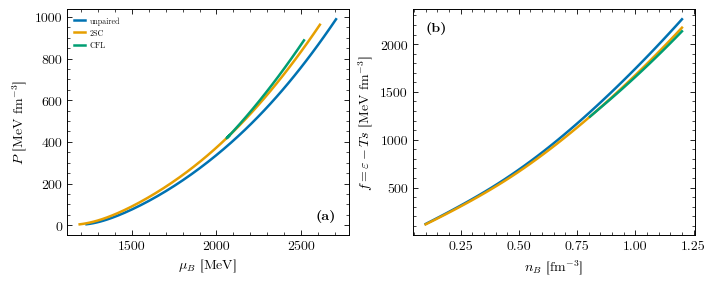

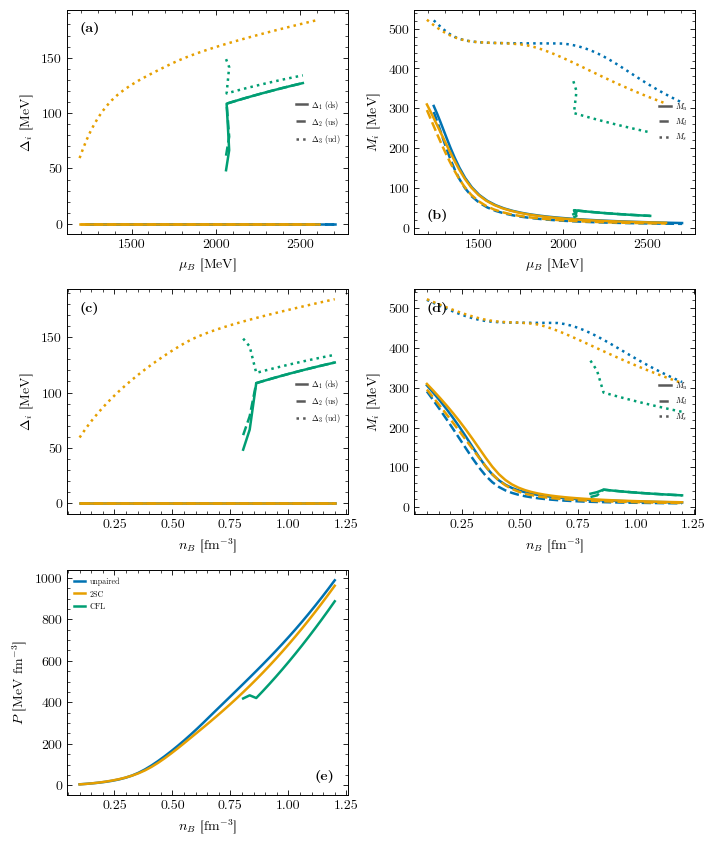

In [ ]:
# ===========================================================================
# njl -- the three pairing branches traced SEPARATELY
#
# One eos_table run per pattern, so each branch is followed on its own instead
# of the free-energy winner being taken at each density. A restriction is not
# a guarantee: a CFL-layout solve below the transition converges with
# Delta_1 = Delta_2 = 0 and comes back as 2SC, so every branch is filtered on
# pattern_realised (eos.njl.api.eos_point).
# ===========================================================================
import time
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

from eos import njl
from eos.general.figure_style import LABELS, OKAB_CAT, panel_label, paper_grid

BR_NB = np.linspace(0.10, 1.20, 40)             # fm^-3
BR_T = 0.0                                      # MeV
BR_MODE = "beta_eq_neutrinoless"
BR_BACKEND = "fast"
BR_PATTERNS = ("unpaired", "2SC", "CFL")
BR_HELD = dict(eta_D=1, eta_V=1.5, vector_form="constant",
               alpha=2.0 / 3.0, n_ref=1, G_V0_over_GS=0.5, M_g=500.0)
BR_PAR = replace(njl.Parameters.named("rkh"), **BR_HELD)
BR_SPECIES = njl.SpeciesFlags(csc=True)
# ---------------------------------------------------------------------------
branches = {}

print(f"=== njl, {BR_MODE}, T = {BR_T} MeV, eta_D = {BR_PAR.eta_D:g}, "
      f"backend = {BR_BACKEND!r}, {len(BR_NB)} densities ===")
for pattern in BR_PATTERNS:
    start = time.perf_counter()
    rows = njl.eos_table(BR_PAR, BR_MODE, BR_SPECIES,
                         {"nB": BR_NB, "T": np.array([BR_T])},
                         rows=True, backend=BR_BACKEND, patterns=(pattern,))
    seconds = time.perf_counter() - start
    realised = [row for row in rows if row["pattern_realised"] == pattern]
    branches[pattern] = realised
    per_point = seconds / len(rows) if rows else float("nan")
    print(f"  {pattern:9s} {len(rows):3d}/{len(BR_NB)} solved, "
          f"{len(realised):3d} realised as {pattern:9s} "
          f"{seconds:7.2f} s total, {per_point:6.3f} s/point")

# The three gaps and the three constituent masses, drawn together per branch:
# colour says which branch, line style which component.
GAP_KEYS = ("Delta_1", "Delta_2", "Delta_3")
MASS_KEYS = ("M_u", "M_d", "M_s")
GAP_TEX = (r"$\Delta_1$ (ds)", r"$\Delta_2$ (us)", r"$\Delta_3$ (ud)")
MASS_TEX = (r"$M_u$", r"$M_d$", r"$M_s$")
COMPONENT_STYLES = ("-", "--", ":")
BRANCH_COLOUR = dict(zip(BR_PATTERNS, OKAB_CAT))


def column(rows, key):
    return np.array([row[key] for row in rows], dtype=float)


# --- P vs mu_B and f vs n_B ------------------------------------------------
fig, axes = paper_grid("1x2", mode="double", placeholder=False, aspect=1.25)
ax_P_mu, ax_f_n = axes[0, 0], axes[0, 1]

for pattern in BR_PATTERNS:
    rows = branches[pattern]
    if not rows:
        print(f"  [{pattern}] no realised rows to draw")
        continue
    colour = BRANCH_COLOUR[pattern]
    n_B, mu_B = column(rows, "n_B"), column(rows, "mu_B")
    # f = eps - T s, the right potential at fixed density -- what the solver
    # ranks the candidates by (eos.njl.solver.solve).
    f = column(rows, "eps") - column(rows, "T") * column(rows, "s")
    ax_P_mu.plot(mu_B, column(rows, "P"), color=colour, label=pattern)
    ax_f_n.plot(n_B, f, color=colour, label=pattern)

ax_P_mu.set_xlabel(LABELS["mu_B"])
ax_P_mu.set_ylabel(LABELS["P"])
ax_P_mu.legend(loc="upper left", fontsize="xx-small")
panel_label(ax_P_mu, "(a)", corner="lower right")

ax_f_n.set_xlabel(LABELS["nB"])
ax_f_n.set_ylabel(r"$f = \varepsilon - Ts$ [MeV fm$^{-3}$]")
panel_label(ax_f_n, "(b)")
plt.show()

# --- gaps, masses and P, against both mu_B and n_B -------------------------
fig2, axes2 = paper_grid("3x2", mode="double", placeholder=False, aspect=1.25)
ax_gap_mu, ax_mass_mu = axes2[0, 0], axes2[0, 1]
ax_gap_n, ax_mass_n = axes2[1, 0], axes2[1, 1]
ax_P_n, ax_blank = axes2[2, 0], axes2[2, 1]
ax_blank.axis("off")

for pattern in BR_PATTERNS:
    rows = branches[pattern]
    if not rows:
        continue
    colour = BRANCH_COLOUR[pattern]
    n_B, mu_B = column(rows, "n_B"), column(rows, "mu_B")
    for keys, ax_mu, ax_n in ((GAP_KEYS, ax_gap_mu, ax_gap_n),
                              (MASS_KEYS, ax_mass_mu, ax_mass_n)):
        for key, style in zip(keys, COMPONENT_STYLES):
            ax_mu.plot(mu_B, column(rows, key), color=colour, ls=style)
            ax_n.plot(n_B, column(rows, key), color=colour, ls=style)
    ax_P_n.plot(n_B, column(rows, "P"), color=colour, label=pattern)

# Colour says which branch, line style which component, so the two keys are
# legended once each rather than on every panel: the branch key rides on the
# P panel, the component key on the gap and mass panels.
for ax, texts in ((ax_gap_mu, GAP_TEX), (ax_gap_n, GAP_TEX),
                  (ax_mass_mu, MASS_TEX), (ax_mass_n, MASS_TEX)):
    proxies = [plt.Line2D([], [], color="0.35", ls=style, label=text)
               for style, text in zip(COMPONENT_STYLES, texts)]
    ax.legend(handles=proxies, loc="center right", fontsize="xx-small")

ax_gap_mu.set_xlabel(LABELS["mu_B"])
ax_gap_mu.set_ylabel(r"$\Delta_i$ [MeV]")
panel_label(ax_gap_mu, "(a)")

ax_mass_mu.set_xlabel(LABELS["mu_B"])
ax_mass_mu.set_ylabel(r"$M_i$ [MeV]")
panel_label(ax_mass_mu, "(b)", corner="lower left")

ax_gap_n.set_xlabel(LABELS["nB"])
ax_gap_n.set_ylabel(r"$\Delta_i$ [MeV]")
panel_label(ax_gap_n, "(c)")

ax_mass_n.set_xlabel(LABELS["nB"])
ax_mass_n.set_ylabel(r"$M_i$ [MeV]")
panel_label(ax_mass_n, "(d)")

ax_P_n.set_xlabel(LABELS["nB"])
ax_P_n.set_ylabel(LABELS["P"])
ax_P_n.legend(loc="upper left", fontsize="xx-small")
panel_label(ax_P_n, "(e)", corner="lower right")
plt.show()


In [ ]:
# %%
# ===========================================================================
# njl -- (eta_D, eta_V) scan of the pairing gaps, and the Alford CSC bag
# model each phase branch maps onto.
#
# Each pattern is walked DOWN a coarse density ladder on its own
# (eos.njl.table.branch_ladder): downward because a paired branch exists at
# the top of the range and ends somewhere below, so the seed is always the
# root one step away -- an ASCENDING CFL sweep stitches two roots together
# and comes back with mu_B(n_B) non-monotone.
#
# The map: P(mu) = 3 a4 mu^4/(4 pi^2) - 3 (m_s^2 - 4 Delta0^2) mu^2/(4 pi^2) - B,
# mu = mu_B/3  (Alford, Braby, Paris, Reddy, ApJ 629, 969 (2005)). Its pairing
# term is +3 Delta0^2 mu^2/pi^2, and the NJL condensation pressure is
# (sum_i Delta_i^2) mu^2/pi^2 for BOTH 2SC and CFL, so one definition serves
# every phase:  Delta0_eff = sqrt(sum_i Delta_i^2 / 3)
# (= Delta for CFL, = Delta_3/sqrt(3) for 2SC, = 0 unpaired).
# m_s and Delta0 enter P(mu) ONLY through (m_s^2 - 4 Delta0^2) and are
# therefore DEGENERATE in the fit: Delta0 is taken from the NJL branch and
# m_s_eff read off the fitted combination.
# ===========================================================================
import time
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

from eos import njl
from eos.njl.table import TableSpec, branch_ladder
from eos.general.figure_style import LABELS, OKAB_CAT, panel_label, paper_grid

SCAN_ETA_D = (0.75, 1.0, 1.25, 1.45, 1.65)
SCAN_ETA_V = (0.0, 0.5, 1.0)
SCAN_NODES = np.linspace(0.40, 1.60, 11)     # ladder nodes [fm^-3]
SCAN_T = 0.0                                 # MeV
SCAN_SET = "rkh"                             # or "rg_njl1", "kunkel"
SCAN_MODE = "beta_eq_neutrinoless"
SCAN_BACKEND = "fast"
SCAN_PATTERNS = ("unpaired", "2SC", "CFL")
SCAN_HELD = dict(vector_form="constant")     # anything else held common
FIT_NB = (0.60, 1.60)                        # window the bag fit is taken over
HBARC = 197.3269804                          # MeV fm
# ---------------------------------------------------------------------------
branches = {}                                # (eta_D, eta_V, pattern) -> points

print(f"=== njl branch scan, {SCAN_MODE}, T = {SCAN_T} MeV, "
      f"{len(SCAN_NODES)} nodes from {SCAN_NODES[0]:g} to {SCAN_NODES[-1]:g} "
      f"fm^-3, backend = {SCAN_BACKEND!r} ===")
for eta_D in SCAN_ETA_D:
    for eta_V in SCAN_ETA_V:
        par = replace(njl.Parameters.named(SCAN_SET), eta_D=eta_D,
                      eta_V=eta_V, **SCAN_HELD)
        spec = TableSpec(par=par, mode=SCAN_MODE,
                         axes={"nB": SCAN_NODES, "T": np.array([SCAN_T])},
                         include=njl.SpeciesFlags(csc=True),
                         backend=SCAN_BACKEND)
        for pattern in SCAN_PATTERNS:
            start = time.perf_counter()
            points = branch_ladder(spec, pattern, SCAN_NODES, SCAN_T, {})
            branches[(eta_D, eta_V, pattern)] = points
            span = (f"{points[0].n_B:.2f}-{points[-1].n_B:.2f}" if points
                    else "none")
            print(f"  eta_D={eta_D:4.2f} eta_V={eta_V:4.2f} {pattern:9s} "
                  f"{len(points):2d}/{len(SCAN_NODES)} nodes, n_B {span:>9s} "
                  f"fm^-3, {time.perf_counter() - start:6.2f} s")


def column(points, key):
    return np.array([getattr(p, key) for p in points], dtype=float)


def delta0_eff(points):
    """The single gap the Alford form wants: sqrt(sum_i Delta_i^2 / 3) [MeV].

    Equals Delta for CFL and Delta_3/sqrt(3) for 2SC, which is exactly what
    makes the one pressure term +3 Delta0^2 mu^2/pi^2 correct in both.
    """
    gaps = np.array([p.Delta for p in points], dtype=float)
    return np.sqrt((gaps ** 2).sum(axis=1) / 3.0)


def fit_bag(points, window=FIT_NB):
    """(a4, alpha_s, B^1/4, m_s_eff, Delta0, fit error) for one branch.

    A linear least squares in (mu^4, mu^2, 1) over the density window -- the
    Alford form IS linear in its three parameters, so there is nothing to
    iterate. `Delta0` is the NJL branch's own mean Delta0_eff, and m_s_eff is
    what the fitted mu^2 coefficient leaves once that is removed.
    """
    keep = [p for p in points if window[0] <= p.n_B <= window[1]]
    if len(keep) < 4:
        return None
    mu = column(keep, "mu_B") / 3.0                     # MeV
    P = column(keep, "P") * HBARC ** 3                  # MeV^4
    basis = np.stack([mu ** 4, mu ** 2, np.ones_like(mu)], axis=1)
    (c4, c2, c0), *_ = np.linalg.lstsq(basis, P, rcond=None)

    a4 = c4 * 4.0 * np.pi ** 2 / 3.0
    Delta0 = float(delta0_eff(keep).mean())
    ms_sq = 4.0 * Delta0 ** 2 - c2 * 4.0 * np.pi ** 2 / 3.0
    B = -c0
    resid = np.abs(basis @ np.array([c4, c2, c0]) - P).max() / np.abs(P).max()
    return dict(a4=a4, alpha_s=np.pi * (1.0 - a4) / 2.0,
                B14=np.sign(B) * np.abs(B) ** 0.25,
                ms_eff=np.sign(ms_sq) * np.sqrt(np.abs(ms_sq)),
                Delta0=Delta0, Delta0_spread=float(np.ptp(delta0_eff(keep))),
                ms_sq_minus_4D2=ms_sq - 4.0 * Delta0 ** 2, err=resid,
                n=len(keep))


print(f"\n=== Alford CSC bag fit, n_B = {FIT_NB[0]}-{FIT_NB[1]} fm^-3 ===")
print(f"  {'eta_D':>5s} {'eta_V':>5s} {'phase':9s} {'a4':>6s} {'alpha_s':>8s} "
      f"{'B^1/4':>8s} {'m_s,eff':>8s} {'Delta0':>8s} {'+-':>6s} "
      f"{'max dP/P':>9s}")
fits = {}
for key, points in branches.items():
    fit = fit_bag(points)
    if fit is None:
        continue
    fits[key] = fit
    eta_D, eta_V, pattern = key
    print(f"  {eta_D:5.2f} {eta_V:5.2f} {pattern:9s} {fit['a4']:6.3f} "
          f"{fit['alpha_s']:8.3f} {fit['B14']:8.1f} {fit['ms_eff']:8.1f} "
          f"{fit['Delta0']:8.1f} {fit['Delta0_spread']:6.1f} "
          f"{fit['err']:9.1e}")

# --- Delta_CFL against Delta_2SC, on the densities both branches reach -----
print("\n=== Delta0_eff: CFL against 2SC ===")
for eta_D in SCAN_ETA_D:
    for eta_V in SCAN_ETA_V:
        two = branches.get((eta_D, eta_V, "2SC"), [])
        cfl = branches.get((eta_D, eta_V, "CFL"), [])
        if not two or not cfl:
            continue
        lo, hi = max(two[0].n_B, cfl[0].n_B), min(two[-1].n_B, cfl[-1].n_B)
        if hi <= lo:
            print(f"  eta_D={eta_D:4.2f} eta_V={eta_V:4.2f}  no shared range")
            continue
        grid = np.linspace(lo, hi, 20)
        d2 = np.interp(grid, column(two, "n_B"), delta0_eff(two))
        dc = np.interp(grid, column(cfl, "n_B"), delta0_eff(cfl))
        g2 = np.interp(grid, column(two, "n_B"),
                       np.array([p.Delta[2] for p in two]))
        gc = np.interp(grid, column(cfl, "n_B"),
                       np.array([p.Delta[2] for p in cfl]))
        print(f"  eta_D={eta_D:4.2f} eta_V={eta_V:4.2f}  "
              f"Delta_3: 2SC {g2.min():5.1f}-{g2.max():5.1f}, "
              f"CFL {gc.min():5.1f}-{gc.max():5.1f} MeV, "
              f"ratio CFL/2SC {(gc / g2).min():4.2f}-{(gc / g2).max():4.2f}; "
              f"Delta0_eff ratio {(dc / d2).min():4.2f}-{(dc / d2).max():4.2f}")

# --- the figures ----------------------------------------------------------
# Colour says eta_D, line style says eta_V; the panels split the phases.
ETA_D_COLOUR = dict(zip(SCAN_ETA_D, OKAB_CAT))
ETA_V_STYLE = dict(zip(SCAN_ETA_V, ("-", "--", "-.", ":")))

fig, axes = paper_grid("2x2", mode="double", placeholder=False, aspect=1.25)
ax_2sc, ax_cfl = axes[0, 0], axes[0, 1]
ax_eff, ax_fit = axes[1, 0], axes[1, 1]

for (eta_D, eta_V, pattern), points in branches.items():
    if not points or pattern == "unpaired":
        continue
    colour, style = ETA_D_COLOUR[eta_D], ETA_V_STYLE[eta_V]
    n_B = column(points, "n_B")
    ax = ax_2sc if pattern == "2SC" else ax_cfl
    # Delta_3 (ud) is the one both phases carry; CFL's Delta_1 (ds) is drawn
    # thin beside it, so the panel shows how far from Delta_1 = Delta_3 it is.
    ax.plot(n_B, [p.Delta[2] for p in points], color=colour, ls=style,
            label=rf"$\eta_D={eta_D:g},\ \eta_V={eta_V:g}$")
    if pattern == "CFL":
        ax.plot(n_B, [p.Delta[0] for p in points], color=colour, ls=style,
                lw=0.8, alpha=0.6)
    ax_eff.plot(n_B, delta0_eff(points), color=colour, ls=style,
                lw=2.0 if pattern == "CFL" else 1.0,
                alpha=1.0 if pattern == "CFL" else 0.6)

for ax, title in ((ax_2sc, "2SC"), (ax_cfl, "CFL")):
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(r"$\Delta_3$ ($ud$) [MeV]")
    ax.set_title(title, fontsize="small")
ax_2sc.legend(loc="lower right", fontsize="xx-small")
panel_label(ax_2sc, "(a)")
panel_label(ax_cfl, "(b)")

ax_eff.set_xlabel(LABELS["nB"])
ax_eff.set_ylabel(r"$\Delta_0^{\rm eff}=\sqrt{\sum_i\Delta_i^2/3}$ [MeV]")
ax_eff.set_title("thick: CFL, thin: 2SC", fontsize="small")
panel_label(ax_eff, "(c)")

# (d) how well the Alford form reproduces each branch it was fitted to.
for key, fit in fits.items():
    eta_D, eta_V, pattern = key
    points = [p for p in branches[key] if FIT_NB[0] <= p.n_B <= FIT_NB[1]]
    mu = column(points, "mu_B") / 3.0
    P = column(points, "P") * HBARC ** 3
    c4 = 3.0 * fit["a4"] / (4.0 * np.pi ** 2)
    c2 = -3.0 * fit["ms_sq_minus_4D2"] / (4.0 * np.pi ** 2)
    P_bag = c4 * mu ** 4 + c2 * mu ** 2 - np.sign(fit["B14"]) * fit["B14"] ** 4
    ax_fit.plot(mu, (P_bag - P) / np.abs(P).max(),
                color=ETA_D_COLOUR[eta_D], ls=ETA_V_STYLE[eta_V],
                lw=2.0 if pattern == "CFL" else 1.0,
                alpha=1.0 if pattern == "CFL" else 0.5)
ax_fit.axhline(0.0, color="0.5", lw=0.8)
ax_fit.set_xlabel(r"$\mu = \mu_B/3$ [MeV]")
ax_fit.set_ylabel(r"$(P_{\rm bag}-P_{\rm NJL})/\max|P_{\rm NJL}|$")
panel_label(ax_fit, "(d)")
plt.show()


=== njl branch scan, beta_eq_neutrinoless, T = 0.0 MeV, 11 nodes from 0.4 to 1.6 fm^-3, backend = 'fast' ===
  eta_D=0.75 eta_V=0.00 unpaired  11/11 nodes, n_B 0.40-1.60 fm^-3,   0.02 s
  eta_D=0.75 eta_V=0.00 2SC       11/11 nodes, n_B 0.40-1.60 fm^-3,   1.35 s
  eta_D=0.75 eta_V=0.00 CFL        5/11 nodes, n_B 1.12-1.60 fm^-3,   2.40 s
  eta_D=0.75 eta_V=0.50 unpaired  11/11 nodes, n_B 0.40-1.60 fm^-3,   0.02 s
  eta_D=0.75 eta_V=0.50 2SC       11/11 nodes, n_B 0.40-1.60 fm^-3,   0.76 s
  eta_D=0.75 eta_V=0.50 CFL        5/11 nodes, n_B 1.12-1.60 fm^-3,   2.04 s
  eta_D=0.75 eta_V=1.00 unpaired  11/11 nodes, n_B 0.40-1.60 fm^-3,   0.02 s
  eta_D=0.75 eta_V=1.00 2SC       11/11 nodes, n_B 0.40-1.60 fm^-3,   0.89 s
  eta_D=0.75 eta_V=1.00 CFL        5/11 nodes, n_B 1.12-1.60 fm^-3,   2.03 s
  eta_D=1.00 eta_V=0.00 unpaired  11/11 nodes, n_B 0.40-1.60 fm^-3,   0.02 s
  eta_D=1.00 eta_V=0.00 2SC       11/11 nodes, n_B 0.40-1.60 fm^-3,   0.79 s
  eta_D=1.00 eta_V=0.00 CFL        7/11 node

AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

In [ ]:
# ===========================================================================
# The visual map: NJL couplings + pairing pattern -> Alford CSC bag numbers.
#
# Reads `fits` and the SCAN_* choices from the cell above. One panel per
# (bag parameter, phase); each panel is the (eta_D, eta_V) plane with the
# fitted number in the cell. A cell drawn with an orange border carries a
# value the bag model MAY NOT HAVE -- a4 outside (0, 1], i.e. alpha_s < 0;
# B < 0; m_s^2 < 0 -- which is the thing to read here: the fit can be
# excellent (panel (d) of the previous cell, ~0.3%) and still land nowhere a
# bag model may go.
# ===========================================================================
# (field, axis label, "is this VALUE one a bag model may carry?")
BAG_ROWS = (("a4", r"$a_4$", lambda v: 0.0 < v <= 1.0),
            ("B14", r"$B^{1/4}$ [MeV]", lambda v: v > 0.0),
            ("ms_eff", r"$m_{s,{\rm eff}}$ [MeV]", lambda v: v >= 0.0),
            ("Delta0", r"$\Delta_0^{\rm eff}$ [MeV]", lambda v: v >= 0.0))
# ---------------------------------------------------------------------------
fig, axes = paper_grid(f"{len(BAG_ROWS)}x{len(SCAN_PATTERNS)}", mode="double",
                       placeholder=False, square=False, aspect=1.0)
for row, (key, ylabel, physical) in enumerate(BAG_ROWS):
    grids = {}
    for pattern in SCAN_PATTERNS:
        grid = np.full((len(SCAN_ETA_D), len(SCAN_ETA_V)), np.nan)
        for i, eta_D in enumerate(SCAN_ETA_D):
            for j, eta_V in enumerate(SCAN_ETA_V):
                fit = fits.get((eta_D, eta_V, pattern))
                if fit is not None:
                    grid[i, j] = fit[key]
        grids[pattern] = grid
    # One colour scale per ROW, so the three phases are comparable across it.
    finite = np.concatenate([g[np.isfinite(g)].ravel() for g in grids.values()])
    vmin, vmax = (finite.min(), finite.max()) if finite.size else (0.0, 1.0)

    for col, pattern in enumerate(SCAN_PATTERNS):
        ax = axes[row, col]
        grid = grids[pattern]
        ax.imshow(grid, origin="lower", aspect="auto", cmap="cividis",
                  vmin=vmin, vmax=vmax,
                  extent=(-0.5, len(SCAN_ETA_V) - 0.5,
                          -0.5, len(SCAN_ETA_D) - 0.5))
        for i, eta_D in enumerate(SCAN_ETA_D):
            for j, eta_V in enumerate(SCAN_ETA_V):
                value = grid[i, j]
                if not np.isfinite(value):
                    ax.text(j, i, "--", ha="center", va="center",
                            fontsize="xx-small", color="0.6")
                    continue
                shade = (value - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                ax.text(j, i,
                        f"{value:.0f}" if abs(value) >= 10 else f"{value:.2f}",
                        ha="center", va="center", fontsize="xx-small",
                        color="w" if shade < 0.55 else "k")
                if not physical(value):
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                               fill=False, edgecolor="#D55E00",
                                               lw=1.6))
        ax.set_xticks(range(len(SCAN_ETA_V)))
        ax.set_yticks(range(len(SCAN_ETA_D)))
        ax.set_xticklabels([f"{v:g}" for v in SCAN_ETA_V], fontsize="xx-small")
        ax.set_yticklabels([f"{v:g}" for v in SCAN_ETA_D], fontsize="xx-small")
        ax.grid(False)
        if row == 0:
            ax.set_title(pattern, fontsize="small")
        if row == len(BAG_ROWS) - 1:
            ax.set_xlabel(r"$\eta_V$")
        if col == 0:
            ax.set_ylabel(ylabel + "\n" + r"$\eta_D$", fontsize="x-small")
fig.suptitle("NJL couplings + pairing pattern  ->  Alford CSC bag parameters\n"
             "(orange border: a value outside the bag model's own window)",
             fontsize="small")
plt.show()


=== eos.njl -> CSC bag, rkh, eta_D=1.45, vector='gluon_exchange', T=0 MeV ===
  phase         a4  alpha_s     m_s   B^1/4  D*_fit  D*_njl   sigma |  rms  P   n_B   n_C   n_S
  unpaired   0.656    0.541   186.5   184.6     0.0     0.0  +0.000 | 7.7e-03 2.1e-02 3.2e-02 6.6e-02  pegged: -   [120 pts, 0 s]
  2SC        0.699    0.473   288.8     0.2   232.2   220.4  +0.413 | 9.7e-03 2.7e-02 4.1e-02 5.1e-02  pegged: -   [120 pts, 12 s]
  CFL        0.518    0.758     0.0   228.5   249.7   249.7  +0.279 | 9.7e-03 2.1e-02 1.6e-12 2.6e-02  pegged: m_s   [10 pts, 7 s]


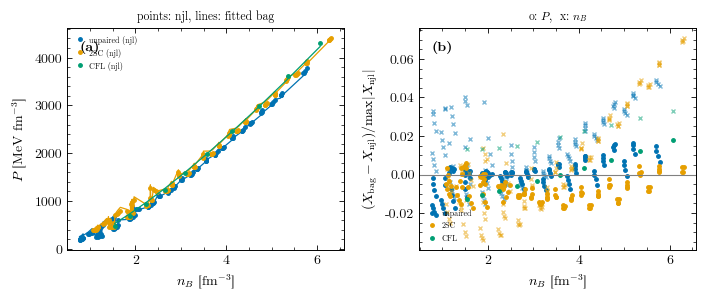

In [6]:
# ===========================================================================
# eos.njl -> an Alford-style colour-superconducting bag model, fitted phase by
# phase in the potentials (mu_B, mu_C, mu_S).  docs/csc_bag_mapping.md is the
# derivation; this is the fit it prescribes.
#
#   P_phase = sum_f P_f(mu_f, T; m_f, a4)
#             + c_phase (sum_f mu_f^2) Delta^2/pi^2 - B
#
# c_phase = 1 (CFL), 1/3 (2SC), 0 (unpaired) -- the count of gapped
# quasiparticles, and the same 3:1 that Geissel, Gorda and Braun
# [arXiv:2504.03834] get for gamma_1 at leading order.
#
# CFL is fitted DIFFERENTLY, and section 5.1 of the document says why: flavour
# locking makes n_C = 0 and n_S = n_B identically, so P depends only on the
# combination mu_B + mu_S and no grid in the three potentials can separate
# m_s from Delta there. For that phase the gap is held at the NJL power law
# and the Alford-Braby-Paris-Reddy polynomial in the common quark potential is
# fitted instead of the flavour-resolved gas.
#
# The fit is separable: at fixed (m_s, sigma) the pressure is LINEAR in
# (a4, Delta_star^2, B), so a bounded linear least squares sits inside a
# one-dimensional minimisation over m_s. The bounds are the bag model's own
# window -- 0 < a4 <= 1, B > 0, m_s >= 0 -- and a parameter that ends up
# pegged is REPORTED, because a fit that only succeeds outside the window is
# telling you the ansatz is missing a term.
# ===========================================================================
import itertools
import time
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear, minimize_scalar

from eos import njl
from eos.alphabag.thermodynamics import fermi_thermo
from eos.mixed import njl_phase
from eos.general.figure_style import LABELS, OKAB_CAT, panel_label, paper_grid

FIT_SET = "rkh"
# MEASURED: with vector_form="constant" the fit fails and the failure is
# structural -- a constant G_V contributes ~ G_V n_q^2, i.e. ~ mu^6, which the
# mu^4/mu^2/const basis cannot hold. Unpaired phase, same grid, rms in P:
# 2.1% at eta_V = 0 (with a4 pegged at 1), 9.8% at eta_V = 0.5, 13.8% at
# eta_V = 1 (both with B pegged at 0), against 3.8% for the gluon-exchange
# form with every parameter inside the window.
FIT_HELD = dict(eta_D=1.45, eta_V=0.0, vector_form="gluon_exchange",
                G_V0_over_GS=0.5, M_g=500.0)
FIT_T = 0.0                                     # MeV
FIT_MU_B = np.linspace(1500.0, 2600.0, 10)      # MeV
FIT_MU_C = np.array([-80.0, -40.0, 0.0, 40.0])  # MeV
FIT_MU_S = np.array([-80.0, 0.0, 80.0])         # MeV
FIT_PATTERNS = ("unpaired", "2SC", "CFL")
MU_STAR = 2600.0                                # MeV, the gap's reference
PI2 = np.pi ** 2
HBARC = 197.3269804
HC3 = HBARC ** 3
#: sum over gapped quasiparticles of Delta_qp^2, as a multiple of
#: (sum_f mu_f^2) Delta^2/pi^2. 1 for CFL (nine modes), 1/3 for 2SC (four).
C_PHASE = {"unpaired": 0.0, "2SC": 1.0 / 3.0, "CFL": 1.0}
# ---------------------------------------------------------------------------
par = replace(njl.Parameters.named(FIT_SET), **FIT_HELD)


def flavour_mu(mu_B, mu_C, mu_S):
    """(mu_u, mu_d, mu_s) from the conserved-charge potentials, S = +1 per s."""
    return (mu_B / 3.0 + 2.0 * mu_C / 3.0,
            mu_B / 3.0 - mu_C / 3.0,
            mu_B / 3.0 - mu_C / 3.0 + mu_S)


def sample(pattern):
    """The NJL phase on the grid, at fixed potentials, one pattern declared."""
    phase = njl_phase(par, njl.SpeciesFlags(csc=True), patterns=(pattern,),
                      backend="fast")
    # CFL: mu_C does not enter and mu_S only through mu_B + mu_S (section 5.1),
    # so a 3-D grid there would be the same line sampled many times over.
    if pattern == "CFL":
        grid = [(mu_B, 0.0, 0.0) for mu_B in FIT_MU_B]
    else:
        grid = list(itertools.product(FIT_MU_B, FIT_MU_C, FIT_MU_S))
    out = []
    for mu_B, mu_C, mu_S in grid:
        try:
            th = phase.thermo(mu_B, mu_C, mu_S, FIT_T)
        except Exception:
            continue
        gaps = np.array([th.fields.get(f"Delta_{i}", 0.0) for i in (1, 2, 3)])
        if C_PHASE[pattern] > 0 and not np.any(np.abs(gaps) > 1.0):
            continue                       # the layout collapsed: not this branch
        out.append(dict(mu_B=mu_B, mu_C=mu_C, mu_S=mu_S, P=th.P, n_B=th.n_B,
                        n_C=th.n_C, n_S=th.n_S,
                        Delta=float(np.sqrt((gaps ** 2).sum() / 3.0))))
    return out


def gap_powerlaw(records):
    """(Delta_star, sigma) of Delta = Delta_star (mu_B/mu_star)^sigma."""
    mu_B = np.array([r["mu_B"] for r in records])
    D = np.array([r["Delta"] for r in records])
    keep = D > 1.0
    if keep.sum() < 3:
        return 0.0, 0.0
    sigma, lnD = np.polyfit(np.log(mu_B[keep] / MU_STAR), np.log(D[keep]), 1)
    return float(np.exp(lnD)), float(sigma)


def bases(mu_B, mu_C, mu_S, m_s, Delta_star, sigma, pattern):
    """(offset, coeff of a4, coeff of Delta_star^2, coeff of B) for P [MeV/fm^3].

    The free gas is `eos.alphabag`'s own: the exact massive Fermi gas plus the
    MASSLESS alpha_s correction, which at T = 0 is exactly (a4 - 1) mu^4/4pi^2,
    so the pressure is strictly LINEAR in a4 and a4 need not be minimised over.
    # ponytail: T = 0 only -- at T > 0 the thermal term carries its own
    # alpha_s factor and a4 moves to the outer minimisation.
    """
    if pattern == "CFL":
        # Locked: one potential, and the ABPR polynomial rather than the
        # flavour-resolved gas (section 5.1).
        mu = (mu_B + mu_S) / 3.0
        offset = 0.0
        c_a4 = 3.0 * mu ** 4 / (4.0 * PI2 * HC3)
        c_ms2 = -3.0 * mu ** 2 / (4.0 * PI2 * HC3)
        c_D2 = 3.0 * (mu_B / MU_STAR) ** (2.0 * sigma) * mu ** 2 / (PI2 * HC3)
        return offset, c_a4, c_ms2, c_D2

    mu_f = flavour_mu(mu_B, mu_C, mu_S)
    masses = (0.0, 0.0, m_s)
    offset = 0.0
    c_a4 = 0.0
    for mu, m in zip(mu_f, masses):
        if mu <= m:
            continue                       # flavour not populated
        free = mu ** 4 / (4.0 * PI2 * HC3)
        offset += fermi_thermo(mu, FIT_T, m)[1] - free
        c_a4 += free
    c_D2 = (C_PHASE[pattern] * sum(m ** 2 for m in mu_f)
            * (mu_B / MU_STAR) ** (2.0 * sigma) / (PI2 * HC3))
    return offset, c_a4, None, c_D2


def rows(records, m_s, Delta_star, sigma, pattern, h=1.0):
    """The linear system: design matrix, right-hand side, and the scales.

    Four rows per grid point -- P and the three charge densities, which are
    first derivatives of the SAME potential and cost nothing extra. The
    derivatives are central differences OF THE MODEL's own basis functions,
    which are elementary, so this is exact to the difference and no chain rule
    has to be maintained by hand.
    """
    def basis_vector(mu_B, mu_C, mu_S):
        off, c_a4, c_ms2, c_D2 = bases(mu_B, mu_C, mu_S, m_s, Delta_star,
                                       sigma, pattern)
        if pattern == "CFL":
            # unknowns (a4, m_s^2, B). Delta is HELD at the NJL power law and
            # its pressure moves into the offset: with only sigma separating
            # m_s^2 from Delta^2 in a locked phase, fitting both is fitting a
            # near-singular system (docs/csc_bag_mapping.md section 5.1).
            return off + Delta_star ** 2 * c_D2, np.array(
                [c_a4, c_ms2, -1.0 / HC3])
        # unknowns (a4, Delta_star^2, B); m_s is the outer parameter
        return off, np.array([c_a4, c_D2, -1.0 / HC3])

    A, b = [], []
    P_scale = max(abs(r["P"]) for r in records)
    n_scale = max(abs(r["n_B"]) for r in records)
    for r in records:
        mu = (r["mu_B"], r["mu_C"], r["mu_S"])
        off0, v0 = basis_vector(*mu)
        A.append(v0 / P_scale)
        b.append((r["P"] - off0) / P_scale)
        # d/d(mu_B, mu_C, mu_S) -> (n_B, n_C, n_S)
        for axis, target in enumerate(("n_B", "n_C", "n_S")):
            hi = list(mu); hi[axis] += h
            lo = list(mu); lo[axis] -= h
            off_hi, v_hi = basis_vector(*hi)
            off_lo, v_lo = basis_vector(*lo)
            A.append((v_hi - v_lo) / (2.0 * h) / n_scale)
            b.append((r[target] - (off_hi - off_lo) / (2.0 * h)) / n_scale)
    return np.array(A), np.array(b), P_scale, n_scale


def fit(records, pattern):
    """One phase: (a4, m_s, B, Delta_star, sigma) inside the physical window."""
    Delta_star, sigma = gap_powerlaw(records)

    def solve_linear(m_s):
        A, b, *_ = rows(records, m_s, Delta_star, sigma, pattern)
        if pattern == "CFL":                    # (a4, m_s^2, B)
            lo = [0.0, 0.0, 0.0]
            hi = [1.0, np.inf, np.inf]
        else:                                   # (a4, Delta*^2, B)
            lo = [0.0, 0.0, 0.0]
            hi = [1.0, np.inf, np.inf]
        res = lsq_linear(A, b, bounds=(lo, hi))
        return res

    if pattern == "CFL":
        res = solve_linear(0.0)
        a4, ms_sq, B = res.x
        m_s, D2 = np.sqrt(ms_sq), Delta_star ** 2
    else:
        # m_s is the one genuinely nonlinear parameter: it sits inside the
        # exact massive gas. One bounded scalar minimisation, no gradient.
        scan = minimize_scalar(lambda m: solve_linear(m).cost,
                               bounds=(0.0, 700.0), method="bounded")
        m_s = float(scan.x)
        res = solve_linear(m_s)
        a4, D2, B = res.x
    n_rows = len(res.fun)
    return dict(a4=a4, alpha_s=np.pi * (1.0 - a4) / 2.0, m_s=m_s,
                B14=B ** 0.25 if B > 0 else 0.0,
                B_MeV4=B, Delta_star=Delta_star, sigma=sigma,
                D2=D2, Delta_fit=float(np.sqrt(max(D2, 0.0))), rms=float(np.sqrt(2.0 * res.cost / n_rows)),
                max_res=float(np.abs(res.fun).max()),
                a4_pegged=bool(a4 >= 1.0 - 1e-9),
                B_pegged=bool(B <= 1e-12),
                n_points=len(records))



print(f"=== eos.njl -> CSC bag, {FIT_SET}, eta_D={par.eta_D:g}, "
      f"vector={par.vector_form!r}, T={FIT_T:g} MeV ===")
print(f"  {'phase':9s} {'a4':>6s} {'alpha_s':>8s} {'m_s':>7s} {'B^1/4':>7s} "
      f"{'D*_fit':>7s} {'D*_njl':>7s} {'sigma':>7s} |  rms  P   n_B   n_C   n_S")
bagfits, bagdata = {}, {}
for pattern in FIT_PATTERNS:
    started = time.perf_counter()
    recs = sample(pattern)
    if len(recs) < 8:
        print(f"  {pattern:9s} only {len(recs)} usable grid points -- skipped")
        continue
    f = fit(recs, pattern)
    bagfits[pattern], bagdata[pattern] = f, recs

    A, b, _, _ = rows(recs, f["m_s"], f["Delta_star"], f["sigma"], pattern)
    x = ([f["a4"], f["m_s"] ** 2, f["B_MeV4"]] if pattern == "CFL"
         else [f["a4"], f["D2"], f["B_MeV4"]])
    resid = (A @ np.array(x) - b).reshape(-1, 4)
    f["resid"] = resid
    pegged = ",".join(name for name, hit in
                      (("a4", f["a4_pegged"]), ("B", f["B_pegged"]),
                       ("m_s", f["m_s"] < 1.0)) if hit) or "-"
    print(f"  {pattern:9s} {f['a4']:6.3f} {f['alpha_s']:8.3f} {f['m_s']:7.1f} "
          f"{f['B14']:7.1f} {f['Delta_fit']:7.1f} {f['Delta_star']:7.1f} "
          f"{f['sigma']:+7.3f} | " +
          " ".join(f"{np.sqrt((resid[:, i] ** 2).mean()):.1e}"
                   for i in range(4)) +
          f"  pegged: {pegged}   [{len(recs)} pts, "
          f"{time.perf_counter() - started:.0f} s]")

# --- how good is the map, and where does it fail --------------------------
fig, axes = paper_grid("1x2", mode="double", placeholder=False, aspect=1.25)
ax_P, ax_r = axes[0, 0], axes[0, 1]
COLOUR = dict(zip(FIT_PATTERNS, OKAB_CAT))
for pattern, f in bagfits.items():
    recs = bagdata[pattern]
    n_B = np.array([r["n_B"] for r in recs])
    P = np.array([r["P"] for r in recs])
    order = np.argsort(n_B)
    ax_P.plot(n_B[order], P[order], "o", ms=2.5, color=COLOUR[pattern],
              label=f"{pattern} (njl)")
    # the fitted model's own pressure, on the same points
    P_bag = P - f["resid"][:, 0] * max(abs(P))
    ax_P.plot(n_B[order], P_bag[order], "-", lw=0.9, color=COLOUR[pattern])
    ax_r.plot(n_B, f["resid"][:, 0], "o", ms=2.5, color=COLOUR[pattern],
              label=pattern)
    ax_r.plot(n_B, f["resid"][:, 1], "x", ms=3, color=COLOUR[pattern],
              alpha=0.5)

ax_P.set_xlabel(LABELS["nB"])
ax_P.set_ylabel(LABELS["P"])
ax_P.legend(loc="upper left", fontsize="xx-small")
ax_P.set_title("points: njl, lines: fitted bag", fontsize="small")
panel_label(ax_P, "(a)")

ax_r.axhline(0.0, color="0.5", lw=0.8)
ax_r.set_xlabel(LABELS["nB"])
ax_r.set_ylabel(r"$(X_{\rm bag}-X_{\rm njl})/\max|X_{\rm njl}|$")
ax_r.set_title(r"o: $P$,  x: $n_B$", fontsize="small")
ax_r.legend(loc="lower left", fontsize="xx-small")
panel_label(ax_r, "(b)")
plt.show()